# Practical Assignment: Score-Based Diffusion via SDEs in 2D (VP-SDE)

**Goal.** Implement and train a small *time-dependent* score network using an SDE formulation of diffusion models on a 2D dataset (mixture of Gaussians), then train a **noise-conditional classifier** and implement **classifier guidance** with a sweep over guidance strength.

**Submission.** Submit this notebook **with outputs saved** (all required figures visible).

---

## Forward SDE (VP-SDE)

We use the variance-preserving SDE on $t\in[0,1]$:
$$
d x_t = -\tfrac12 \beta(t)\, x_t\, dt + \sqrt{\beta(t)}\, dW_t,
\qquad \beta(t)=2.
$$

For training, you will use the closed-form marginal:
$$
x_t = \alpha(t)x_0 + \sigma(t)\varepsilon,\qquad \varepsilon\sim \mathcal N(0,I).
$$

---

## Required outputs

- **Part 1:** (i) scatter snapshots of $x_t$ at multiple times; (ii) table comparing empirical vs theoretical variance at those times. [2 pts]
- **Part 2:** (i) loss curve; (ii) quiver plot of learned score field at a fixed time. [3 pts]
- **Part 3:** figure comparing generated samples vs real samples (no scalar metric required). [1 pt]
- **Part 4:** (i) accuracy-vs-noise curve; (ii) confusion matrices at $t=0.1$ and $t=0.9$. [3 pts]
- **Part 5:** (i) grid of conditional samples for multiple guidance strengths; (ii) curves of conditional accuracy and a diversity proxy vs guidance strength; (iii) report your chosen “best” guidance. [1 pt]

You do **not** need to write long explanations—short comments in Markdown are enough.


In [18]:
# =========================
# Setup (run this cell)
# =========================
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Reproducibility
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)


Device: cpu


## Part 0 (provided): 2D Mixture of Gaussians dataset

We provide a labeled 2D mixture of Gaussians on a circle.  
Class label $y\in\{0,\dots,K-1\}$ is the component index.

Run the cell below to visualize the dataset.


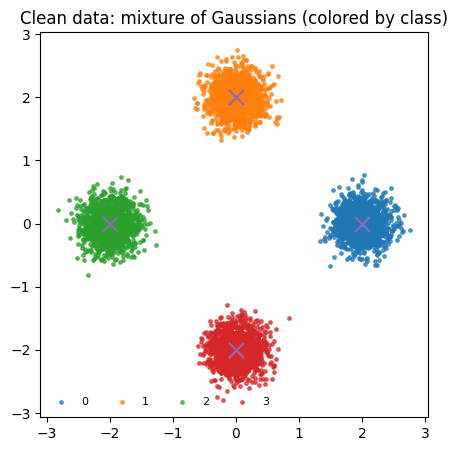

In [19]:
# ==================================
# Part 0: Dataset (provided)
# ==================================
def make_ring_centers(K: int, radius: float = 2.0) -> np.ndarray:
    angles = np.linspace(0, 2*np.pi, K, endpoint=False)
    centers = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    return centers

def sample_mog(n: int, K: int = 4, radius: float = 2.0, std: float = 0.2):
    # Returns x0: (n,2) float32, y: (n,) int64, centers: (K,2)
    centers = make_ring_centers(K, radius)
    y = np.random.randint(0, K, size=(n,))
    x0 = centers[y] + std*np.random.randn(n, 2)
    return x0.astype(np.float32), y.astype(np.int64), centers

def plot_scatter_by_class(x: np.ndarray, y: np.ndarray, centers=None, title=""):
    plt.figure(figsize=(5,5))
    K = int(y.max()) + 1
    for k in range(K):
        pts = x[y == k]
        plt.scatter(pts[:,0], pts[:,1], s=6, alpha=0.7, label=str(k))
    if centers is not None:
        plt.scatter(centers[:,0], centers[:,1], s=120, marker="x")
    plt.axis("equal")
    plt.title(title)
    plt.legend(ncol=4, fontsize=8, frameon=False)
    plt.show()

# Visualize dataset
K = 4
x0, y0, centers = sample_mog(6000, K=K, radius=2.0, std=0.22)
plot_scatter_by_class(x0, y0, centers=centers, title="Clean data: mixture of Gaussians (colored by class)")


## Part 1: Forward noising via VP-SDE marginals

### Task 1.1 (implement)
Implement the schedule $\beta(t)$ and the corresponding closed-form $\alpha(t)$ and $\sigma(t)$.

For $\beta(t)=2$,
$$
\int_0^t \beta(s)\,ds = 2 t,
\qquad
\alpha(t) = \exp\!\left(-\tfrac12\int_0^t\beta(s)\,ds\right),
\qquad
\sigma(t)=\sqrt{1-\alpha(t)^2}.
$$

### Task 1.2 (implement)
Implement `q_sample(x0, t)` that returns `(xt, eps)` with
$$
x_t = \alpha(t)x_0 + \sigma(t)\varepsilon.
$$

### Required outputs
1. A row of scatter plots for $t \in \{0,0.25,0.5,0.75,1\}$.
2. A small printed table comparing empirical per-dimension variance of $x_t$ with the theoretical value.


In [20]:
# ==================================
# Part 1: Forward process (TODO)
# ==================================


def beta_t(t: torch.Tensor) -> torch.Tensor:
    # t: shape (B,1) or (B,)
    # returns: shape like t
    # TODO: implement
    #assignments says b=2 so I'm creating a tensor of 2 with the shape of t
    return torch.ones_like(t) * 2.0


def alpha_t(t: torch.Tensor) -> torch.Tensor:
    # Closed-form alpha(t) for VP-SDE with beta(t)=2.
    # TODO: implement using integral of beta(s).
    # a=1 at time t is 100% left, a=.37 is 37% left of the original image
    return torch.exp(-t)


def sigma_t(t: torch.Tensor) -> torch.Tensor:
    # sigma(t) = sqrt(1 - alpha(t)^2)
    # TODO: implement
    #we're adding noise
    alpha = alpha_t(t)
    sigma = torch.sqrt(1.0 - alpha * alpha)
    return sigma.clamp(min=1e-3)

def q_sample(x0: torch.Tensor, t: torch.Tensor):
    # Sample from q(x_t | x_0) using the closed form:
    #   x_t = alpha(t) * x0 + sigma(t) * eps
    # Returns:
    #   xt: (B,2)
    #   eps: (B,2)
    # TODO: implement
    #applying previous functions
    eps = torch.randn_like(x0)
    alpha = alpha_t(t)
    sigma = sigma_t(t)
    xt = alpha * x0 + sigma * eps

    return xt, eps

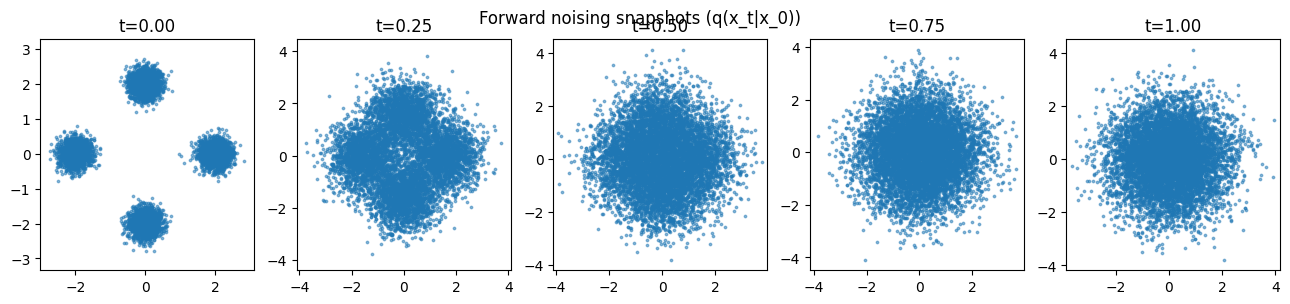

t | Var_emp(x_t)[0] Var_emp(x_t)[1] | Var_th[0] Var_th[1]
0.00 | 2.0468 2.0524 | 2.0468 2.0524
0.25 | 1.6174 1.6493 | 1.6349 1.6383
0.50 | 1.3899 1.3914 | 1.3851 1.3871
0.75 | 1.2170 1.2408 | 1.2336 1.2348
1.00 | 1.1607 1.1377 | 1.1417 1.1424


In [21]:
# ==================================
# Part 1: Required output cell (run after TODOs)
# ==================================
B = 8000
x0_np, y_np, centers = sample_mog(B, K=K, radius=2.0, std=0.22)
x0_t = torch.from_numpy(x0_np).to(device)

ts = [0.0, 0.25, 0.5, 0.75, 1.0]
xt_list = []
var_table = []

var_x0 = x0_t.var(dim=0, unbiased=False).detach().cpu().numpy()

for tval in ts:
    t = torch.full((B,1), float(tval), device=device)
    xt, eps = q_sample(x0_t, t)
    xt_list.append(xt.detach().cpu().numpy())

    var_emp = xt.var(dim=0, unbiased=False).detach().cpu().numpy()

    a = alpha_t(t)[0].detach().cpu().item()
    s = sigma_t(t)[0].detach().cpu().item()
    var_th = (a*a)*var_x0 + (s*s)*np.ones_like(var_x0)

    var_table.append((tval, var_emp[0], var_emp[1], var_th[0], var_th[1]))

plt.figure(figsize=(16,3))
for i, tval in enumerate(ts):
    plt.subplot(1, len(ts), i+1)
    xt = xt_list[i]
    plt.scatter(xt[:,0], xt[:,1], s=3, alpha=0.5)
    plt.title(f"t={tval:.2f}")
    plt.axis("equal")
plt.suptitle("Forward noising snapshots (q(x_t|x_0))")
plt.show()

print("t | Var_emp(x_t)[0] Var_emp(x_t)[1] | Var_th[0] Var_th[1]")
for row in var_table:
    print(f"{row[0]:.2f} | {row[1]:.4f} {row[2]:.4f} | {row[3]:.4f} {row[4]:.4f}")


## Part 2: Train a time-dependent score network $s_\theta(x,t)$

Train an MLP to approximate the score using the denoising target:
$$
\nabla_{x_t}\log q(x_t\mid x_0) = -\varepsilon/\sigma(t).
$$

### Task 2.1 (implement time dependence)
You must implement **some time embedding**. Please, be free to experiment and report what you found.

### Task 2.2 (train)
Train the score network on random $t\sim U[0,1]$.

### Required outputs
1. Loss curve.
2. Quiver plot of the learned score field at $t=0.5$.
3. Score MSE on a held-out batch.


In [22]:
# ==================================
# Part 2: Time embeddings (TODO)
# ==================================
class TimeEmbedding(nn.Module):
    # Fourier features for scalar t in [0,1]. Output size = 2*F (sin/cos).
    # TODO: implement time embedding
    def __init__(self, F: int = 32):
        super().__init__()
        self.F = F
        freqs = 2.0 ** torch.arange(F)  # [1, 2, 4, 8, 16 etc] creating frequencies bins
        self.register_buffer('freqs', freqs) #these are not like tensors, they are not trainable, but its easier to handle

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # TODO: implement time embedding forward method
        # Make sure t is at least 2D
        if t.dim() == 1: #fix shape if needed
            t = t.unsqueeze(-1)
        frequencies = t * self.freqs #we're scaling time with frequencie

        #then we apply sin and cosin to each freq, they are periodic so they get cyclic patterns. we get phase and amplitute info
        sin_emb = torch.sin(frequencies)
        cos_emb = torch.cos(frequencies)

            #and we concatenate
        embedding = torch.cat([sin_emb, cos_emb], dim=-1)

        return embedding




In [23]:
# ==================================
# Part 2: Score model (TODO in forward)
# ==================================
class ScoreNet(nn.Module):
    def __init__(self, hidden: int = 128, time_F: int = 32):
        super().__init__()
        self.time_emb = TimeEmbedding(F=time_F) #createin the embedding module
        time_dim = 2 * time_F #this is to calculate the output dimension
        # TODO: implement your architecture here. You can use any MLP structure you like, just remember to incorporate the time embedding.
        input_dim = 2 + time_dim
        #Smooth activation (no sharp corners), i googled reccomeded activation functions for diffusion models
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.SiLU(),

            nn.Linear(hidden, hidden),
            nn.SiLU(),

            nn.Linear(hidden, hidden),
            nn.SiLU(),

            nn.Linear(hidden, 2)
        )



    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor: #passing everything through
        # x: (B,2), t: (B,1)
        # Return: score estimate (B,2)
        # TODO: implement time embedding + concat + network forward.
        t_emb = self.time_emb(t)
        h = torch.cat([x, t_emb], dim=-1)
        score = self.net(h)  # (B, 2)

        return score

score_model = ScoreNet(hidden=128, time_F=32).to(device)
print("Score model parameters:", sum(p.numel() for p in score_model.parameters()))


Score model parameters: 41858


In [24]:
# ==================================
# Part 2: Training loop
# ==================================
def sample_batch(B: int, K: int):
    x0_np, y_np, _ = sample_mog(B, K=K, radius=2.0, std=0.22)
    x0 = torch.from_numpy(x0_np).to(device)
    y  = torch.from_numpy(y_np).to(device)
    return x0, y

def train_score_model(
    model: nn.Module,
    steps: int = 15000,
    batch_size: int = 1024,
    lr: float = 2e-4,
    print_every: int = 500,
):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for it in range(1, steps+1):
        x0, _ = sample_batch(batch_size, K=K)
        t = torch.rand(batch_size, 1, device=device)
        xt, eps = q_sample(x0, t)

        sig = sigma_t(t)
        target = -eps / sig

        pred = model(xt, t)
        loss = F.mse_loss(pred, target) # Standard L2 loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(float(loss.detach().cpu()))
        if it % print_every == 0:
            print(f"step {it:>6d} | loss {losses[-1]:.6f}")

    return np.array(losses, dtype=np.float32)

# ===== Run training =====
losses = train_score_model(score_model, steps=15000, batch_size=1024, lr=2e-4)


step    500 | loss 3.382468
step   1000 | loss 7.527194
step   1500 | loss 5.465765
step   2000 | loss 16.604536
step   2500 | loss 5.299835
step   3000 | loss 3.819322
step   3500 | loss 2.531330
step   4000 | loss 3.643485
step   4500 | loss 3.469471
step   5000 | loss 2.045707
step   5500 | loss 74.761269
step   6000 | loss 8.545909
step   6500 | loss 7.311922
step   7000 | loss 2.187690
step   7500 | loss 2.000074
step   8000 | loss 3.195737
step   8500 | loss 4.233624
step   9000 | loss 2.147999
step   9500 | loss 8.434193
step  10000 | loss 3.724505
step  10500 | loss 1.824568
step  11000 | loss 2.356419
step  11500 | loss 7.947042
step  12000 | loss 2.913206
step  12500 | loss 2.666403
step  13000 | loss 1.624290
step  13500 | loss 2.442296
step  14000 | loss 1.456438
step  14500 | loss 2.499117
step  15000 | loss 2.571651


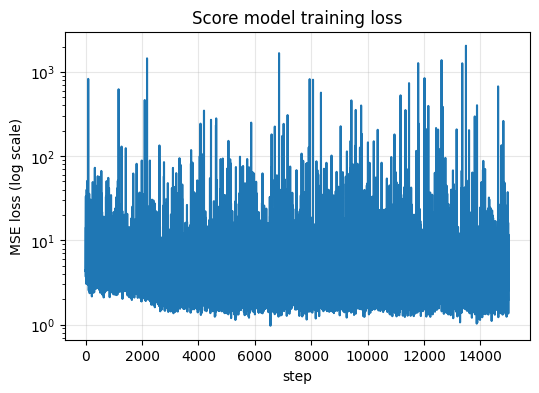

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


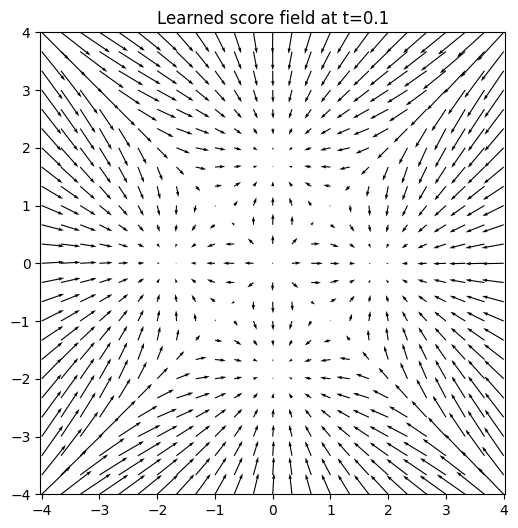

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


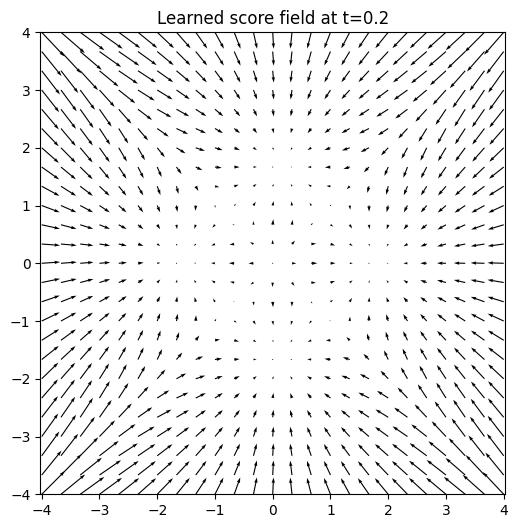

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


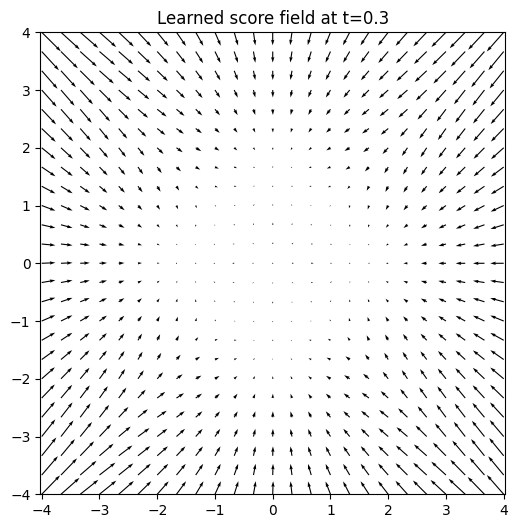

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


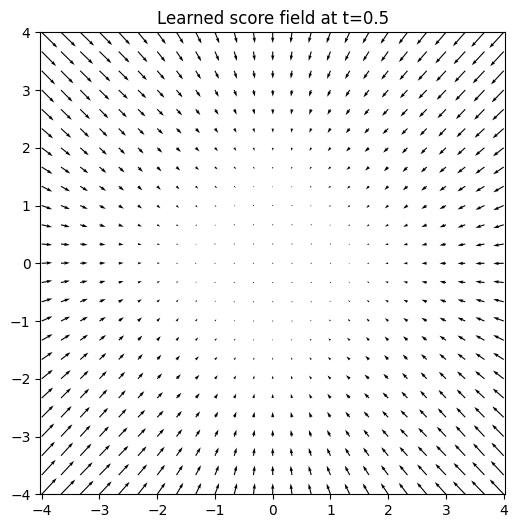

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


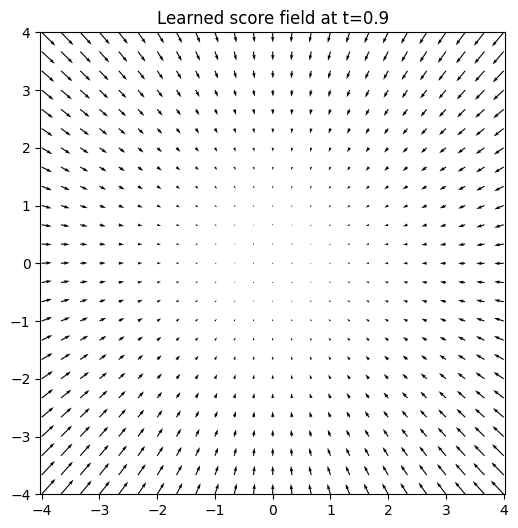

In [25]:
# ==================================
# Part 2: Required outputs (run after training)
# ==================================
def plot_loss_curve(losses: np.ndarray):
    plt.figure(figsize=(6,4))
    plt.plot(losses)
    plt.yscale("log")
    plt.xlabel("step")
    plt.ylabel("MSE loss (log scale)")
    plt.title("Score model training loss")
    plt.grid(True, alpha=0.3)
    plt.show()

@torch.no_grad()
def quiver_score_field(model: nn.Module, tval: float = 0.5, lim: float = 4.0, grid: int = 25):
    model.eval()
    xs = np.linspace(-lim, lim, grid)
    ys = np.linspace(-lim, lim, grid)
    X, Y = np.meshgrid(xs, ys)
    pts = np.stack([X.reshape(-1), Y.reshape(-1)], axis=1).astype(np.float32)
    x = torch.from_numpy(pts).to(device)
    t = torch.full((x.shape[0], 1), float(tval), device=device)
    s = model(x, t).detach().cpu().numpy()

    plt.figure(figsize=(6,6))
    plt.quiver(pts[:,0], pts[:,1], s[:,0], s[:,1], angles="xy", scale_units="xy", scale=25)
    plt.title(f"Learned score field at t={tval}")
    plt.axis("equal")
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.show()

plot_loss_curve(losses)
quiver_score_field(score_model, tval=0.1)
quiver_score_field(score_model, tval=0.2)
quiver_score_field(score_model, tval=0.3)
quiver_score_field(score_model, tval=0.5)
quiver_score_field(score_model, tval=0.9)

## Part 3: Unconditional sampling via reverse-time SDE

Reverse-time SDE (informal form):
$$
dx = \big(f(x,t) - g(t)^2 s_\theta(x,t)\big)\,dt + g(t)\,d\bar W_t,
\quad \text{integrate from } t=1 \to 0.
$$
For VP-SDE: $f(x,t)=-\tfrac12\beta(t)x$ and $g(t)=\sqrt{\beta(t)}$.

### Task 3.1 (implement sampler)
Implement Euler–Maruyama for the reverse SDE.

### Required output
- One figure: generated samples vs real data (side-by-side or overlaid).


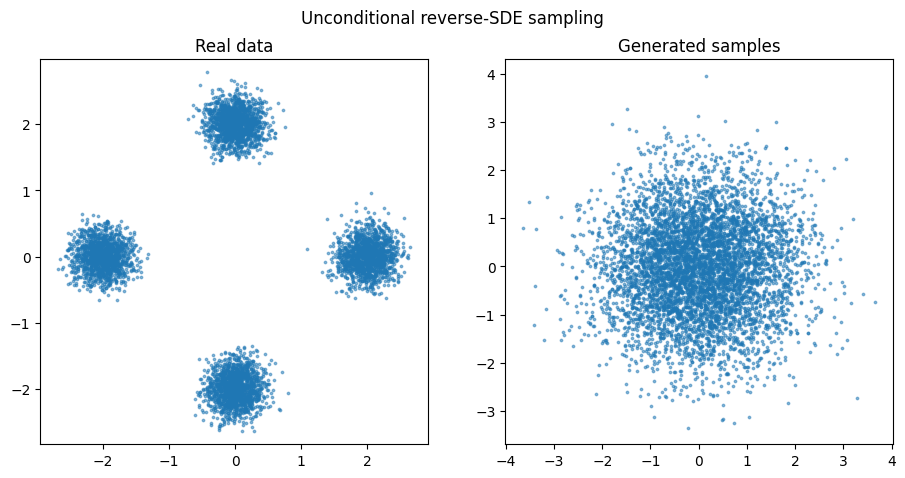

In [26]:
# ==================================
# Part 3: Reverse SDE sampler (TODO)
# ==================================
@torch.no_grad()
def sample_reverse_sde(
    score_fn,
    n_samples: int = 5000,
    n_steps: int = 400,
):
    # score_fn(x, t) -> (B,2)
    # TODO: implement Euler-Maruyama from t=1 to t=0.
    #
    # Notes:
    #  - Start from x_1 ~ N(0, I)
    x = torch.randn(n_samples, 2, device=device)
    #  - Use dt = -1/n_steps (negative)
    dt = -1.0 / n_steps

    #sampling
    t = torch.ones(n_samples, 1, device=device) #start a t = 1
    for step in range(n_steps):
        #  - Clamp t to [1e-5, 1.0] for stability
        t = torch.clamp(t, min=1e-5)
        #drift term
        f_x = -x
        score = score_fn(x, t)
        drift = f_x - 2.0 * score
        #diffusion term
        sqrt_dt = torch.sqrt(torch.tensor(abs(dt), device=device))
        noise = torch.randn_like(x) * sqrt_dt
        diffusion = np.sqrt(2.0) * noise  # g(t) = sqrt(2) (?)
        #E-M update
        x = x + drift * dt + diffusion
        t = t + dt
        return x


def plot_generated_vs_real(x_gen: np.ndarray, x_real: np.ndarray, title=""):
    plt.figure(figsize=(11,5))
    plt.subplot(1,2,1)
    plt.scatter(x_real[:,0], x_real[:,1], s=3, alpha=0.5)
    plt.title("Real data")
    plt.axis("equal")

    plt.subplot(1,2,2)
    plt.scatter(x_gen[:,0], x_gen[:,1], s=3, alpha=0.5)
    plt.title("Generated samples")
    plt.axis("equal")

    plt.suptitle(title)
    plt.show()

x_gen = sample_reverse_sde(score_model, n_samples=6000, n_steps=400).cpu().numpy()
x_real, _, _ = sample_mog(6000, K=K, radius=2.0, std=0.22)
plot_generated_vs_real(x_gen, x_real, title="Unconditional reverse-SDE sampling")


## Part 4: Train a noise-conditional classifier $p_\phi(y\mid x_t,t)$

Train a classifier that takes **noisy** inputs $(x_t,t)$ and predicts the mixture component label $y$.

### Task 4.1 (implement classifier with time dependence)
Implement a small MLP classifier with a time embedding.

### Task 4.2 (train)
Train on pairs $(x_t,t)$ generated from sampled $(x_0,y)$.

### Required outputs
1. Accuracy vs noise: plot accuracy as a function of $t$ (bin $t$ into ~10 bins). You should notice that the confusion goes to around 50 %. Explain why this happens if we have four components and the perfect uncertainty is 25 %.
2. Confusion matrices at $t=0.1$ and $t=0.9$.


In [27]:
# ==========================z========
# Part 4: Noise-conditional classifier (TODO)
# ==================================
class NoiseCondClassifier(nn.Module):
    def __init__(self, num_classes: int, hidden: int = 128, time_F: int = 32):
        super().__init__()
        self.time_emb = TimeEmbedding(F=time_F)
        time_dim = 2 * time_F
        # TODO: implement your architecture
        input_dim = 2 + time_dim
        #added droput
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(hidden, hidden),
            nn.ReLU(),

            nn.Linear(hidden, num_classes)
        )


    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # Return logits (B,K).
        # TODO: implement time embedding + concat + network forward.
        t_emb = self.time_emb(t)
        h = torch.cat([x, t_emb], dim=-1)
        logits = self.net(h)
        return logits

clf = NoiseCondClassifier(num_classes=K, hidden=128).to(device)
print("Classifier parameters:", sum(p.numel() for p in clf.parameters()))


Classifier parameters: 42116


In [28]:
# ==================================
# Part 4: Training loop
# ==================================
def train_classifier(
    model: nn.Module,
    steps: int = 8000,
    batch_size: int = 1024,
    lr: float = 2e-4,
    print_every: int = 500,
):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for it in range(1, steps+1):
        x0, y = sample_batch(batch_size, K=K)
        t = torch.rand(batch_size, 1, device=device)
        xt, _ = q_sample(x0, t)

        logits = model(xt, t)
        loss = F.cross_entropy(logits, y)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(float(loss.detach().cpu()))
        if it % print_every == 0:
            print(f"step {it:>6d} | loss {losses[-1]:.6f}")

    return np.array(losses, dtype=np.float32)

# ===== Run training =====
clf_losses = train_classifier(clf, steps=8000, batch_size=1024, lr=2e-4)


step    500 | loss 0.639938
step   1000 | loss 0.620229
step   1500 | loss 0.603036
step   2000 | loss 0.599025
step   2500 | loss 0.571518
step   3000 | loss 0.559305
step   3500 | loss 0.605616
step   4000 | loss 0.604699
step   4500 | loss 0.667748
step   5000 | loss 0.590616
step   5500 | loss 0.590029
step   6000 | loss 0.620227
step   6500 | loss 0.565059
step   7000 | loss 0.595439
step   7500 | loss 0.586691
step   8000 | loss 0.605053


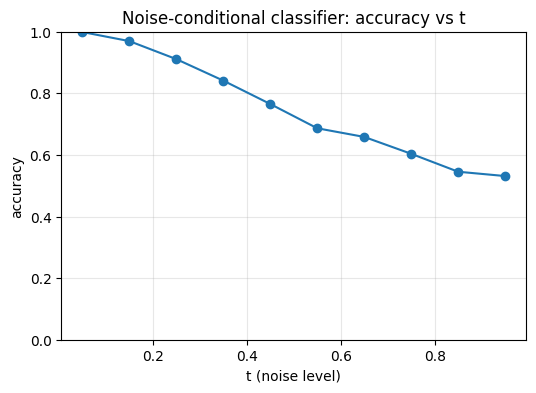

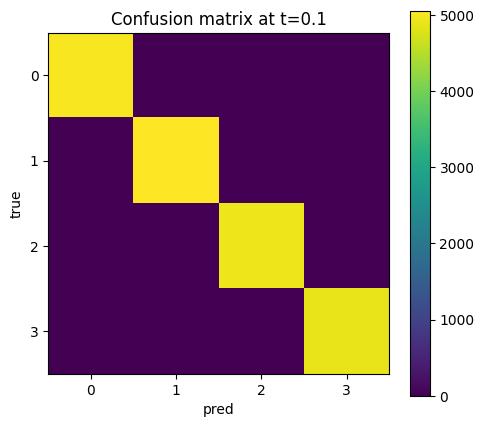

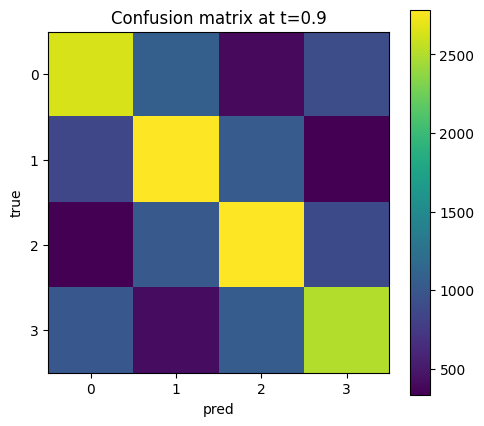

In [29]:
# ==================================
# Part 4: Required outputs (run after training)
# ==================================
@torch.no_grad()
def accuracy_vs_t(model: nn.Module, n_eval: int = 20000, n_bins: int = 10):
    model.eval()
    x0_np, y_np, _ = sample_mog(n_eval, K=K, radius=2.0, std=0.22)
    x0 = torch.from_numpy(x0_np).to(device)
    y  = torch.from_numpy(y_np).to(device)

    t = torch.rand(n_eval, 1, device=device)
    xt, _ = q_sample(x0, t)

    logits = model(xt, t)
    pred = logits.argmax(dim=1)

    t_np = t.detach().cpu().numpy().reshape(-1)
    pred_np = pred.detach().cpu().numpy()
    y_np2 = y.detach().cpu().numpy()

    bins = np.linspace(0, 1, n_bins+1)
    acc = []
    mids = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (t_np >= lo) & (t_np < hi)
        mids.append(0.5*(lo+hi))
        acc.append(np.nan if mask.sum()==0 else (pred_np[mask] == y_np2[mask]).mean())
    return np.array(mids), np.array(acc)

@torch.no_grad()
def confusion_matrix_at_t(model: nn.Module, tval: float, n_eval: int = 20000):
    model.eval()
    x0_np, y_np, _ = sample_mog(n_eval, K=K, radius=2.0, std=0.22)
    x0 = torch.from_numpy(x0_np).to(device)
    y  = torch.from_numpy(y_np).to(device)
    t  = torch.full((n_eval,1), float(tval), device=device)
    xt, _ = q_sample(x0, t)
    pred = model(xt, t).argmax(dim=1)

    cm = torch.zeros((K, K), device=device, dtype=torch.int64)
    for yi, pi in zip(y, pred):
        cm[yi, pi] += 1
    return cm.detach().cpu().numpy()

def plot_confusion(cm: np.ndarray, title=""):
    plt.figure(figsize=(5.5,5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.colorbar()
    plt.xticks(range(K))
    plt.yticks(range(K))
    plt.show()

mids, acc = accuracy_vs_t(clf, n_eval=20000, n_bins=10)
plt.figure(figsize=(6,4))
plt.plot(mids, acc, marker="o")
plt.ylim(0, 1.0)
plt.xlabel("t (noise level)")
plt.ylabel("accuracy")
plt.title("Noise-conditional classifier: accuracy vs t")
plt.grid(True, alpha=0.3)
plt.show()

plot_confusion(confusion_matrix_at_t(clf, tval=0.1), title="Confusion matrix at t=0.1")
plot_confusion(confusion_matrix_at_t(clf, tval=0.9), title="Confusion matrix at t=0.9")


## Part 5: Classifier guidance (noise-conditional)

Guided score:
$$
s_{\text{guided}}(x_t,t;y)= s_\theta(x_t,t) + w\,\nabla_{x_t}\log p_\phi(y\mid x_t,t).
$$

### Task 5.1 (implement guidance gradient)
Compute $\nabla_x \log p_\phi(y\mid x,t)$ with autograd.

### Task 5.2 (guidance sweep)
For a fixed target class $y^\star$ and strengths $w\in\{0,1,2,5,10\}$:
- Sample from the reverse SDE using the guided score.
- Compute:
  - conditional accuracy: classifier predicts $y^\star$ at $(x_0,t=0)$,
  - diversity proxy: $\mathrm{tr}(\widehat{\mathrm{Cov}}(x_0))$.

### Required outputs
1. Grid of scatter plots (one per $w$).
2. Plot of conditional accuracy vs $w$ and diversity proxy vs $w$.
3. Report your chosen “best $w$” (one sentence).


In [30]:
# ==================================
# Part 5: Classifier guidance utilities (TODO)
# ==================================
def guided_score_fn_factory(score_model: nn.Module, clf: nn.Module, y_target: int, w: float):
    # Returns a function score_fn(x, t) -> guided score (B,2).
    # Uses:
    #   s_guided = s_theta(x,t) + w * grad_x log p_phi(y_target | x, t)
    # TODO: implement using autograd.
    def guided_score_fn(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        clf.train()
        #had a few probalmes with passnig this
        x = x.detach().requires_grad_(True)


        with torch.no_grad():
            score = score_model(x, t)

        # fixed the issue here
        with torch.enable_grad():
            logits = clf(x, t)
            log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
            log_p_target = log_probs[:, y_target]

            grad = torch.autograd.grad(
                outputs=log_p_target.sum(),
                inputs=x,
                create_graph=False,
                retain_graph=False,
                allow_unused=True
            )[0]

        if grad is None:
            grad = torch.zeros_like(x)

        guided_score = score + w * grad
        return guided_score

    return guided_score_fn

@torch.no_grad()
def conditional_metrics(clf: nn.Module, x0: torch.Tensor, y_target: int):
    # conditional accuracy at t=0
    B = x0.shape[0]
    t0 = torch.zeros((B,1), device=x0.device)
    logits = clf(x0, t0)
    pred = logits.argmax(dim=1)
    acc = (pred == y_target).float().mean().item()

    # diversity proxy: trace of covariance
    xc = x0 - x0.mean(dim=0, keepdim=True)
    cov = (xc.T @ xc) / B
    div = torch.trace(cov).item()
    return acc, div


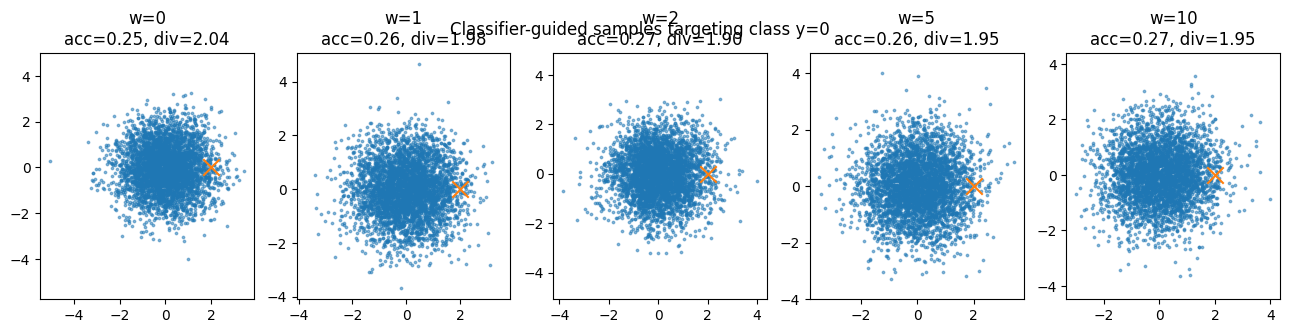

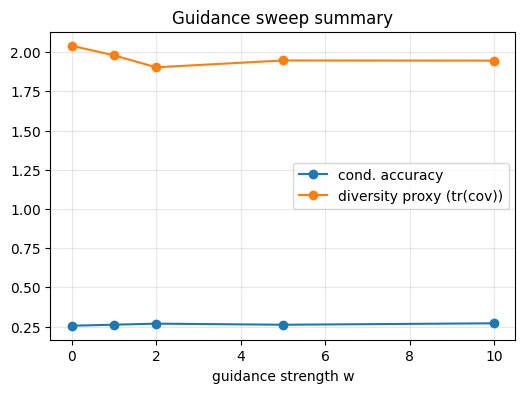

In [31]:
# ==================================
# Part 5: Required outputs (run after implementing guidance + sampler)
# ==================================
y_star = 0
w_list = [0.0, 1.0, 2.0, 5.0, 10.0]

# NOTE: requires sample_reverse_sde implemented and score_model + clf trained.
results = []
for w in w_list:
    score_fn = guided_score_fn_factory(score_model, clf, y_target=y_star, w=w)
    x_gen = sample_reverse_sde(score_fn, n_samples=4000, n_steps=400).to(device)
    acc, div = conditional_metrics(clf, x_gen, y_target=y_star)
    results.append((w, x_gen.detach().cpu().numpy(), acc, div))

# Grid of samples
cols = len(w_list)
plt.figure(figsize=(3.2*cols, 3.2))
for i, (w, x_np, acc, div) in enumerate(results):
    plt.subplot(1, cols, i+1)
    plt.scatter(x_np[:,0], x_np[:,1], s=3, alpha=0.5)
    plt.scatter(centers[y_star,0], centers[y_star,1], s=140, marker="x")
    plt.title(f"w={w:g}\nacc={acc:.2f}, div={div:.2f}")
    plt.axis("equal")
plt.suptitle(f"Classifier-guided samples targeting class y={y_star}")
plt.show()

# Accuracy/diversity vs w
ws = np.array([r[0] for r in results])
accs = np.array([r[2] for r in results])
divs = np.array([r[3] for r in results])

plt.figure(figsize=(6,4))
plt.plot(ws, accs, marker="o", label="cond. accuracy")
plt.plot(ws, divs, marker="o", label="diversity proxy (tr(cov))")
plt.xlabel("guidance strength w")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Guidance sweep summary")
plt.show()
